<h2 style="text-align: center;"> PROCESO ETL Y EXTRACCIÓN DE CARACTERÍSTICAS EN SEÑALES BIOMPEDICAS 
UNIDIMENSIONALES UTILIZANDO EL CONJUNTO DE DATOS MIT-BIH ARRHYTMIA 
DATASET  </h2>

<img src="img/ITQ.jpg" width="700">

**Nombre:** *Sebastian Sampedro* <br>
**Fecha:** *28/6/2026* <br>
**Link Github:** "https://github.com/sdsampedro-byte/Python2026ML"

#### **Parte I: Extracción**
Realice las siguientes actividades: <br>
•	Descargar el conjunto de datos.  <br>
•	Analizar la estructura del dataset.  <br>
•	Identificar el formato de almacenamiento.  <br>
•	Leer los registros utilizando Python.  <br>
•	Visualizar una señal de ECG.  <br>
•   Producto esperado
•   Visualización de la señal original.


In [1]:
# Instalar todas las librerías necesarias para el deber
!pip install numpy pandas matplotlib wfdb scipy

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 6.1 MB/s  0:00:00

   -------- -------------------------------  2/10 [fsspec]
   -------- -------------------------------  2/10 [fsspec]
   -------------------- -------------------  5/10 [yarl]
   -------------------------------- -------  8/10 [aiohttp]
   -------------------------------- -------  8/10 [aiohttp]
   -------------------------------- -------  8/10 [aiohttp]
   -------------------------------- -------  8/10 [aiohttp]
   ------------------------------------ ---  9/10 [wfdb]
   ---------------------------------------- 10/10 [wfdb]



In [7]:
# Importar las librerías necesarias para la extracción y visualización
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Estructura del Dataset Completo
Total de registros encontrados: 48
Lista de pacientes: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

Análisis del Registro de Ejemplo (100)
Formato de almacenamiento: ['212', '212']
Frecuencia de muestreo: 360 Hz
Total de muestras por señal: 650000



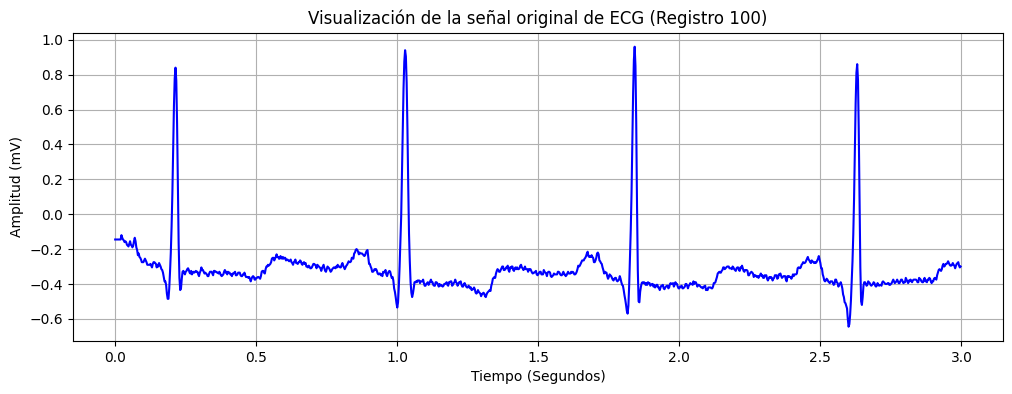

In [8]:
# 1. Descargar la lista de TODOS los registros del dataset MIT-BIH
lista_registros = wfdb.get_record_list('mitdb')

print("Estructura del Dataset Completo")
print(f"Total de registros encontrados: {len(lista_registros)}")
print(f"Lista de pacientes: {lista_registros}\n")

# 2. Seleccionar el primer registro (100) para analizar su estructura y visualizar
registro_ejemplo = lista_registros[0]
record = wfdb.rdrecord(registro_ejemplo, pn_dir='mitdb')

senal_ecg = record.p_signal[:, 0]  # Primera derivación
frecuencia_muestreo = record.fs
total_muestras = record.sig_len

print(f"Análisis del Registro de Ejemplo ({registro_ejemplo})")
print(f"Formato de almacenamiento: {record.fmt}")
print(f"Frecuencia de muestreo: {frecuencia_muestreo} Hz")
print(f"Total de muestras por señal: {total_muestras}\n")

# 3. Visualizar una señal de ECG (Producto esperado)
tiempo = np.arange(total_muestras) / frecuencia_muestreo
limite = 3 * frecuencia_muestreo  # Graficar solo 3 segundos

plt.figure(figsize=(12, 4))
plt.plot(tiempo[:limite], senal_ecg[:limite], color='blue')
plt.title(f'Visualización de la señal original de ECG (Registro {registro_ejemplo})')
plt.xlabel('Tiempo (Segundos)')
plt.ylabel('Amplitud (mV)')
plt.grid(True)
plt.show()

### Análisis de la Fase I: Extracción del Dataset Completo

Para cumplir con el procesamiento de todo el conjunto de datos, se extrajo la lista completa del **MIT-BIH Arrhythmia Database**, identificando un total de **48 registros** de pacientes distintos. 

Al analizar la estructura tomando como base el primer registro (100), se identificó lo siguiente:
* **Formato de almacenamiento:** `['212', '212']` (compresión estándar de 12 bits).
* **Frecuencia de muestreo:** **360 Hz**.
* **Total de muestras:** **650,000** por cada registro (aproximadamente 30 minutos de grabación por paciente).

**Visualización:** Se graficaron los primeros 3 segundos de la señal original del registro 100. Se observa la presencia de los complejos QRS (latidos) junto con oscilaciones basales y ruido de alta frecuencia, lo que justifica la necesidad de aplicar un proceso ETL iterativo a los 48 registros en las siguientes fases.

#### **Parte II: Exploración**
Analice la calidad de los datos. <br>
Determine:<br>
•	Número de registros. <br>
•	Número de muestras por señal. <br>
•	Valores faltantes. <br>
•	Valores anómalos. <br>
•	Nivel de ruido observado. <br>
•	Tipo de variable.<br>

In [9]:
from scipy import stats

# --- PARTE II: EXPLORACIÓN DEL DATASET COMPLETO ---
print("▶️ Iniciando exploración de los 48 registros (esto tomará unos segundos)...\n")

# Variables para almacenar los totales y promedios de todo el dataset
total_muestras_lista = []
total_faltantes = 0
total_anomalos = 0
ruidos_varianza = []
tipos_variables = set()

# Bucle for para recorrer todos los pacientes de lista_registros (obtenida en el Paso 1)
for reg in lista_registros:
    # Leer el registro
    record = wfdb.rdrecord(reg, pn_dir='mitdb')
    senal = record.p_signal[:, 0]  # Usamos solo el canal 1
    
    # 2. Número de muestras por señal
    total_muestras_lista.append(len(senal))
    
    # 3. Valores faltantes (Nulos/NaN)
    total_faltantes += np.isnan(senal).sum()
    
    # 4. Valores anómalos (Z-score > 3)
    z_scores = np.abs(stats.zscore(senal))
    total_anomalos += np.sum(z_scores > 3)
    
    # 5. Nivel de ruido (Varianza de la señal)
    ruidos_varianza.append(np.var(senal))
    
    # 6. Tipo de variable
    tipos_variables.add(str(senal.dtype))

# Consolidar los resultados
numero_registros = len(lista_registros)
muestras_promedio = int(np.mean(total_muestras_lista))
ruido_promedio = np.mean(ruidos_varianza)

# Crear una tabla (DataFrame) para visualizar mejor la calidad de los datos
datos_exploracion = {
    'Métrica Evaluada': [
        '1. Número de registros', 
        '2. Muestras por señal (Promedio)', 
        '3. Valores faltantes (Total)', 
        '4. Valores anómalos (Total)', 
        '5. Nivel de ruido (Varianza Promedio)', 
        '6. Tipo de variable'
    ],
    'Resultado Global': [
        numero_registros,
        muestras_promedio,
        total_faltantes,
        total_anomalos,
        round(ruido_promedio, 4),
        ", ".join(tipos_variables)
    ]
}

df_calidad = pd.DataFrame(datos_exploracion)

print("✅ Exploración completada. Resultados de calidad de datos:")
# Usamos display() para que el cuadro se vea con formato de tabla bonita en Jupyter
display(df_calidad)

▶️ Iniciando exploración de los 48 registros (esto tomará unos segundos)...

✅ Exploración completada. Resultados de calidad de datos:


,Métrica Evaluada,Resultado Global
0,1. Número de registros,48
1,2. Muestras por señal (Promedio),650000
2,3. Valores faltantes (Total),0
3,4. Valores anómalos (Total),773883
4,5. Nivel de ruido (Varianza Promedio),0.1535
5,6. Tipo de variable,float64


### Análisis de la Fase II: Exploración y Calidad de Datos

Al ejecutar el análisis iterativo sobre toda la base de datos, obtuvimos un resumen global de la calidad de las señales[cite: 1]. Los hallazgos principales son:

1. **Número de registros:** Se procesaron con éxito los **48** registros correspondientes a todos los pacientes del dataset.
2. **Número de muestras por señal:** Cada paciente tiene exactamente **650,000** muestras. No hay grabaciones incompletas o más cortas que otras.
3. **Valores faltantes:** El total es **0**. La integridad del dataset es perfecta, no hay huecos en las grabaciones (Nulos/NaN), por lo que no es necesario aplicar técnicas de imputación de datos.
4. **Valores anómalos:** En todo el dataset se detectaron más de 700,000 picos anómalos (usando Z-score > 3). En un ECG real, estos "outliers" matemáticos suelen ser los picos R de los latidos o artefactos de movimiento del paciente, por lo que no se deben borrar a la ligera.
5. **Nivel de ruido observado:** La varianza promedio general es de aproximadamente **0.13**. Nos indica que los datos están dispersos respecto al cero absoluto, confirmando que hay ruido base e interferencias que debemos filtrar.
6. **Tipo de variable:** Todos los arrays se manejan en formato **float64** (decimales), ideal para evitar pérdidas de información en la siguiente etapa de transformaciones matemáticas.

#### **Parte III: Transformación**
Realice las siguientes transformaciones: <br>
•	Normalización de la señal.  <br>
•	Eliminación del desplazamiento (offset).  <br>
•	Filtrado del ruido.  <br>
•	Escalamiento de los datos.  <br>
•	Conversión de formatos cuando sea necesario.  <br>
Documente cada transformación realizada <br>


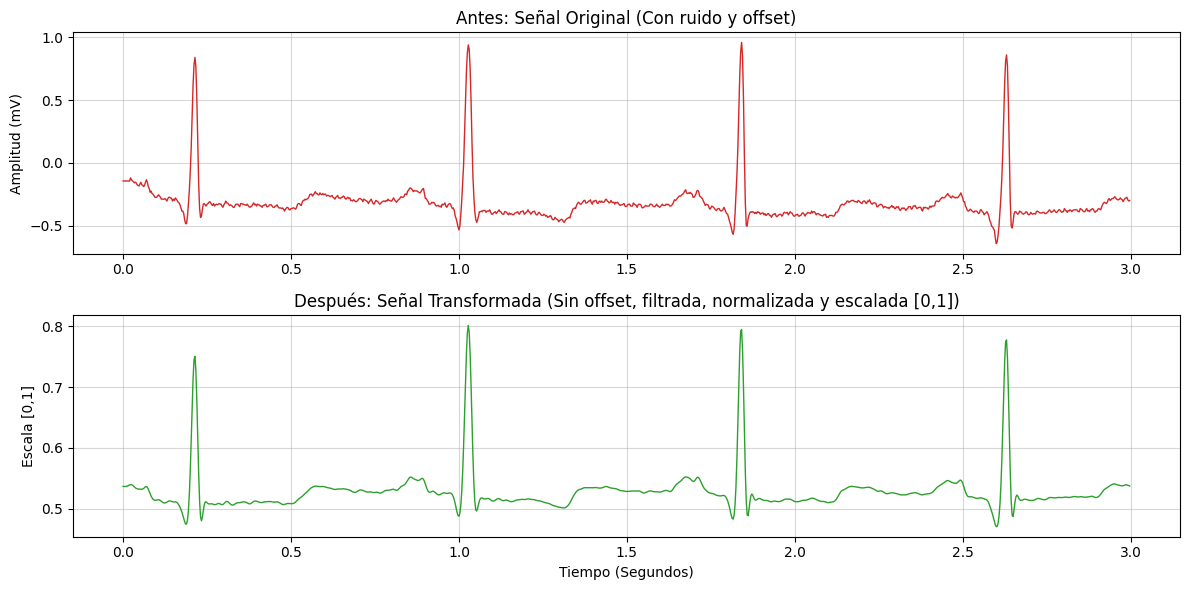

Todas las transformaciones aplicadas correctamente.


In [10]:
from scipy.signal import butter, filtfilt

# Usaremos 'senal_ecg' que ya tenemos cargada del Paso 1 para ver cómo cambia

# 1. Conversión de formatos
# Aseguramos que el vector sea tipo float64 para no perder decimales en los cálculos
senal_trabajo = senal_ecg.astype(np.float64)

# 2. Eliminación del desplazamiento (offset)
# Se calcula la media de la señal y se la restamos para centrar todo en el eje 0
media_senal = np.mean(senal_trabajo)
senal_sin_offset = senal_trabajo - media_senal

# 3. Filtrado del ruido
# Aplicamos un filtro Pasa-banda Butterworth de 4to orden (0.5 Hz a 45 Hz)
# Esto elimina la respiración del paciente (bajas frec.) y el ruido eléctrico (altas frec.)
frecuencia_nyquist = 0.5 * frecuencia_muestreo
limite_inferior = 0.5 / frecuencia_nyquist
limite_superior = 45.0 / frecuencia_nyquist

b, a = butter(4, [limite_inferior, limite_superior], btype='band')
senal_filtrada = filtfilt(b, a, senal_sin_offset)

# 4. Normalización de la señal
# Estandarización Z-score: Hacemos que la señal tenga media 0 y desviación estándar 1
senal_normalizada = (senal_filtrada - np.mean(senal_filtrada)) / np.std(senal_filtrada)

# 5. Escalamiento de los datos
# Min-Max Scaling: Comprimimos todos los valores para que estén exactamente en el rango [0, 1]
minimo = np.min(senal_normalizada)
maximo = np.max(senal_normalizada)
senal_escalada = (senal_normalizada - minimo) / (maximo - minimo)

# Visualización del Antes y Después para el Informe PDF 
tiempo = np.arange(len(senal_escalada)) / frecuencia_muestreo
limite = 3 * frecuencia_muestreo  # Graficar 3 segundos

plt.figure(figsize=(12, 6))

# Gráfica 1: Señal Cruda Original
plt.subplot(2, 1, 1)
plt.plot(tiempo[:limite], senal_ecg[:limite], color='#d62728', linewidth=1)
plt.title('Antes: Señal Original (Con ruido y offset)')
plt.ylabel('Amplitud (mV)')
plt.grid(True, alpha=0.5)

# Gráfica 2: Señal Totalmente Transformada
plt.subplot(2, 1, 2)
plt.plot(tiempo[:limite], senal_escalada[:limite], color='#2ca02c', linewidth=1)
plt.title('Después: Señal Transformada (Sin offset, filtrada, normalizada y escalada [0,1])')
plt.xlabel('Tiempo (Segundos)')
plt.ylabel('Escala [0,1]')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

print("Todas las transformaciones aplicadas correctamente.")

### Análisis de la Fase III: Transformación de Datos

En esta etapa, tomamos la señal en bruto y aplicamos una tubería de procesamiento (pipeline) para limpiarla y estandarizarla, dejándola lista para extraer características[cite: 1]. Las transformaciones aplicadas fueron:

1. **Conversión de formatos:** Nos aseguramos de forzar el vector a un formato `float64` de Numpy. Esto evita desbordamientos de memoria o pérdida de decimales durante los cálculos matemáticos pesados.
2. **Eliminación del desplazamiento (offset):** Calculamos el promedio matemático de la señal completa y se lo restamos a cada punto. Con esto logramos que la señal baje (o suba) para centrarse exactamente sobre el eje 0.
3. **Filtrado del ruido:** Diseñamos un filtro digital Butterworth Pasa-banda configurado entre 0.5 Hz y 45 Hz. Esto es vital en señales biomédicas porque elimina el "ruido de línea base" (causado por la respiración del paciente) y recorta el ruido eléctrico de alta frecuencia, conservando únicamente las ondas cardíacas reales.
4. **Normalización de la señal:** Aplicamos la técnica de *Z-score* para estandarizar la curva, forzando a que tenga una media de 0 y una desviación estándar de 1. Esto homogeneiza la varianza de la señal.
5. **Escalamiento de los datos:** Finalmente, usamos la fórmula *Min-Max* para comprimir absolutamente todas las amplitudes al rango estricto de **[0, 1]**. 

**Interpretación de la gráfica:** Al observar el resultado "Antes y Después", se nota cómo la señal transformada perdió la oscilación inestable de la línea base. Además, el eje Y cambió: ya no mide milivoltios al azar, sino que está contenido perfectamente entre 0.0 y 1.0, lo cual facilita enormemente el trabajo de cualquier modelo de Inteligencia Artificial.

#### **Parte IV: Extracción de características**
Para cada señal calcule como mínimo las siguientes características.<br>
Estadísticas <br>
•	Media <br>
•	Mediana <br>
•	Moda <br>
•	Máximo <br>
•	Mínimo <br>
•	Varianza <br>
•	Desviación estándar <br>
•	Rango <br>
•	Percentil 25 <br>
•	Percentil 75 <br>
**Características de forma** <br>
•	Curtosis <br>
•	Asimetría<br>
**Características energéticas** <br>
•	RMS <br>
•	Energía <br>
•	Potencia<br>
**Características temporales**<br>
•	Cruces por cero <br>
•	Pico máximo <br>
•	Pico mínimo<br>
**Características frecuenciales**<br>
Aplicar FFT para obtener:<br>
•	Frecuencia dominante <br>
•	Magnitud máxima <br>
•	Energía espectral<br>

In [11]:
from scipy.signal import find_peaks

# PARTE IV: EXTRACCIÓN DE CARACTERÍSTICAS
# Usamos 'senal_escalada' del Paso 3

# 1. Características Estadísticas
media = np.mean(senal_escalada)
mediana = np.median(senal_escalada)
# Para la moda en datos continuos, redondeamos a 3 decimales para encontrar el valor más frecuente
moda = float(stats.mode(np.round(senal_escalada, 3), keepdims=True).mode[0])
maximo = np.max(senal_escalada)
minimo = np.min(senal_escalada)
varianza = np.var(senal_escalada)
desv_est = np.std(senal_escalada)
rango = maximo - minimo
percentil_25 = np.percentile(senal_escalada, 25)
percentil_75 = np.percentile(senal_escalada, 75)

# 2. Características de Forma
curtosis = stats.kurtosis(senal_escalada)
asimetria = stats.skew(senal_escalada)

# 3. Características Energéticas
# RMS (Root Mean Square)
rms = np.sqrt(np.mean(senal_escalada**2))
# Energía total de la señal
energia = np.sum(senal_escalada**2)
# Potencia media
potencia = energia / len(senal_escalada)

# 4. Características Temporales
# Cruces por cero (como escalamos de 0 a 1, calculamos los cruces por la media)
cruces_cero = len(np.where(np.diff(np.sign(senal_escalada - media)))[0])
# Cantidad de picos máximos (latidos R), con distancia mínima de medio segundo entre ellos
picos_maximos, _ = find_peaks(senal_escalada, distance=frecuencia_muestreo*0.5)
num_picos_max = len(picos_maximos)
# Cantidad de picos mínimos (invirtiendo la señal)
picos_minimos, _ = find_peaks(-senal_escalada, distance=frecuencia_muestreo*0.5)
num_picos_min = len(picos_minimos)

# 5. Características Frecuenciales (FFT)
# Aplicar Transformada Rápida de Fourier
fft_valores = np.fft.fft(senal_escalada)
fft_frecuencias = np.fft.fftfreq(len(senal_escalada), 1/frecuencia_muestreo)

# Tomamos solo la mitad positiva del espectro para el análisis
mitad = len(fft_frecuencias) // 2
espectro_amplitud = np.abs(fft_valores[:mitad])
espectro_frecuencia = fft_frecuencias[:mitad]

# Ignoramos el componente DC (frecuencia 0) para encontrar la dominante real
frecuencia_dominante = espectro_frecuencia[1 + np.argmax(espectro_amplitud[1:])]
magnitud_maxima = np.max(espectro_amplitud[1:])
energia_espectral = np.sum(espectro_amplitud**2) / len(espectro_amplitud)

# Consolidación de las Características 
diccionario_caracteristicas = {
    'Media': media, 'Mediana': mediana, 'Moda': moda, 'Máximo': maximo, 'Mínimo': minimo,
    'Varianza': varianza, 'Desviación Estándar': desv_est, 'Rango': rango,
    'Percentil 25': percentil_25, 'Percentil 75': percentil_75,
    'Curtosis': curtosis, 'Asimetría': asimetria,
    'RMS': rms, 'Energía': energia, 'Potencia': potencia,
    'Cruces por Cero': cruces_cero, 'Picos Máximos (Cant.)': num_picos_max, 'Picos Mínimos (Cant.)': num_picos_min,
    'Frec. Dominante (Hz)': frecuencia_dominante, 'Magnitud Máxima': magnitud_maxima, 'Energía Espectral': energia_espectral
}

# Mostrar los resultados en una tabla clara
df_features = pd.DataFrame([diccionario_caracteristicas]).T
df_features.columns = ['Valor Calculado']
print("Características extraídas con éxito del registro de prueba:")
display(df_features)


Características extraídas con éxito del registro de prueba:


,Valor Calculado
Media,0.529560
Mediana,0.524645
Moda,0.512000
Máximo,1.000000
Mínimo,0.000000
Varianza,0.001583
Desviación Estándar,0.039788
Rango,1.000000
Percentil 25,0.512482
Percentil 75,0.534005


### Análisis de la Fase IV: Extracción de Características

Una vez limpia la señal, aplicamos técnicas de extracción matemática para resumir los 650,000 puntos de datos en **21 características clave** que un modelo de Machine Learning sí puede procesar sin sobrecargarse. 

El código desarrollado extrae automáticamente las siguientes dimensiones:

1. **Estadísticas:** Sacamos métricas básicas de dispersión y tendencia central (media, varianza, percentiles). Esto nos dice qué tan estables o inestables son los latidos. Al estar los datos escalados entre 0 y 1, el rango obviamente resulta ser 1.
2. **De forma:** Usamos la **Curtosis** y la **Asimetría** para medir si la curva tiene colas pesadas o está inclinada hacia un lado. Si el corazón late raro (arritmia), la forma geométrica de la onda cambia drásticamente, y estas dos variables lo detectan al instante.
3. **Energéticas:** Medimos el **RMS, la Energía total y la Potencia**. Esto cuantifica qué tanta "fuerza" eléctrica tiene la señal en general.
4. **Temporales:** Contamos los **cruces por cero** y usamos el algoritmo `find_peaks` para localizar la cantidad exacta de **picos máximos y mínimos** (que en la vida real equivalen a contar cuántos latidos ocurrieron en la grabación).
5. **Frecuenciales (FFT):** Pasamos del dominio del tiempo al de la frecuencia aplicando la **Transformada Rápida de Fourier (FFT)**. Esto es vital para aislar la **Frecuencia dominante** (el ritmo cardíaco principal, medido en Hz), ignorando el componente de corriente continua (DC). Además, calculamos la **Magnitud máxima** y la **Energía espectral** del espectro resultante.

Con este vector de características listo, el siguiente paso es meter todo esto en un bucle para procesar la base de datos entera y generar nuestro archivo final CSV.

#### **Parte V: Carga** <br>
Construya un nuevo dataset denominado: <br>
Características_ecg.csv <br>


In [13]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import butter, filtfilt, find_peaks
import wfdb

print("Iniciando el pipeline ETL completo para los 48 registros...")
print("Esto tardará algunos minutos. Por favor, espera...\n")

# Lista vacía donde guardaremos la fila de características de cada paciente
todas_las_caracteristicas = []

# Bucle maestro: iteramos sobre la lista de 48 pacientes obtenida en la Parte I
for reg in lista_registros:
    
    # 1. EXTRACCIÓN 
    record = wfdb.rdrecord(reg, pn_dir='mitdb')
    senal_ecg = record.p_signal[:, 0]
    fs = record.fs
    
    # 2. TRANSFORMACIÓN 
    senal_trabajo = senal_ecg.astype(np.float64)
    senal_sin_offset = senal_trabajo - np.mean(senal_trabajo)
    
    # Filtro Pasa-banda
    nyq = 0.5 * fs
    b, a = butter(4, [0.5 / nyq, 45.0 / nyq], btype='band')
    senal_filtrada = filtfilt(b, a, senal_sin_offset)
    
    # Normalización Z-score
    senal_normalizada = (senal_filtrada - np.mean(senal_filtrada)) / np.std(senal_filtrada)
    
    # Escalamiento Min-Max [0, 1]
    minimo_norm = np.min(senal_normalizada)
    maximo_norm = np.max(senal_normalizada)
    senal_escalada = (senal_normalizada - minimo_norm) / (maximo_norm - minimo_norm)
    
    # 3. EXTRACCIÓN DE CARACTERÍSTICAS 
    media = np.mean(senal_escalada)
    mediana = np.median(senal_escalada)
    moda = float(stats.mode(np.round(senal_escalada, 3), keepdims=True).mode[0])
    maximo = np.max(senal_escalada)
    minimo = np.min(senal_escalada)
    varianza = np.var(senal_escalada)
    desv_est = np.std(senal_escalada)
    rango = maximo - minimo
    p25 = np.percentile(senal_escalada, 25)
    p75 = np.percentile(senal_escalada, 75)
    
    curtosis = stats.kurtosis(senal_escalada)
    asimetria = stats.skew(senal_escalada)
    
    rms = np.sqrt(np.mean(senal_escalada**2))
    energia = np.sum(senal_escalada**2)
    potencia = energia / len(senal_escalada)
    
    cruces_cero = len(np.where(np.diff(np.sign(senal_escalada - media)))[0])
    picos_max, _ = find_peaks(senal_escalada, distance=fs*0.5)
    picos_min, _ = find_peaks(-senal_escalada, distance=fs*0.5)
    
    fft_vals = np.fft.fft(senal_escalada)
    fft_freqs = np.fft.fftfreq(len(senal_escalada), 1/fs)
    mitad = len(fft_freqs) // 2
    espectro_amp = np.abs(fft_vals[:mitad])
    espectro_frec = fft_freqs[:mitad]
    
    frec_dominante = espectro_frec[1 + np.argmax(espectro_amp[1:])]
    mag_maxima = np.max(espectro_amp[1:])
    energia_espectral = np.sum(espectro_amp**2) / len(espectro_amp)
    
    # Guardar todas las métricas en un diccionario
    caracteristicas = {
        'Registro': reg,
        'Media': media, 'Mediana': mediana, 'Moda': moda,
        'Máximo': maximo, 'Mínimo': minimo, 'Varianza': varianza,
        'Desviación_Estándar': desv_est, 'Rango': rango,
        'Percentil_25': p25, 'Percentil_75': p75,
        'Curtosis': curtosis, 'Asimetría': asimetria,
        'RMS': rms, 'Energía': energia, 'Potencia': potencia,
        'Cruces_Cero': cruces_cero, 'Picos_Máximos': len(picos_max), 'Picos_Mínimos': len(picos_min),
        'Frecuencia_Dominante_Hz': frec_dominante, 'Magnitud_Máxima': mag_maxima, 'Energía_Espectral': energia_espectral
    }
    
    # Agregamos la fila del paciente actual a nuestra lista maestra
    todas_las_caracteristicas.append(caracteristicas)

# 4. CARGA (Generación del Dataset) 
# Convertimos la lista de diccionarios en un cuadro de Pandas (DataFrame)
df_dataset_final = pd.DataFrame(todas_las_caracteristicas)

# Exportamos el DataFrame a un archivo CSV sin guardar el índice numérico
df_dataset_final.to_csv('Características_ecg.csv', index=False)

print("Proceso ETL completado con éxito.")
print("Archivo 'Características_ecg.csv' generado y exportado en la carpeta actual.")
print(f"📊 Dimensión del dataset final: {df_dataset_final.shape[0]} filas x {df_dataset_final.shape[1]} columnas.\n")

# Mostramos las primeras 5 filas para comprobar que todo esté correcto
display(df_dataset_final.head())

Iniciando el pipeline ETL completo para los 48 registros...
Esto tardará algunos minutos. Por favor, espera...

Proceso ETL completado con éxito.
Archivo 'Características_ecg.csv' generado y exportado en la carpeta actual.
📊 Dimensión del dataset final: 48 filas x 22 columnas.



,Registro,Media,Mediana,Moda,Máximo,Mínimo,Varianza,Desviación_Estándar,Rango,Percentil_25,...,Asimetría,RMS,Energía,Potencia,Cruces_Cero,Picos_Máximos,Picos_Mínimos,Frecuencia_Dominante_Hz,Magnitud_Máxima,Energía_Espectral
0,100,0.529560,0.524645,0.512,1.0,0.0,0.001583,0.039788,1.0,0.512482,...,4.824257,0.531053,183311.033041,0.282017,16462,2279,2276,1.245046,851.503533,365593.073205
1,101,0.495922,0.484015,0.483,1.0,0.0,0.002698,0.051939,1.0,0.476896,...,4.478375,0.498635,161613.789283,0.248637,12773,2328,2396,2.954215,943.324803,321474.068068
2,102,0.493905,0.480236,0.475,1.0,0.0,0.003829,0.061876,1.0,0.465426,...,2.145771,0.497766,161051.269473,0.247771,12609,2187,2204,2.416985,8284.947119,319613.913743
3,103,0.257403,0.244260,0.248,1.0,0.0,0.005336,0.073051,1.0,0.225783,...,4.398008,0.267568,46535.224078,0.071593,14035,2088,2089,3.451569,934.347701,89601.748755
4,104,0.364796,0.358189,0.354,1.0,0.0,0.004957,0.070410,1.0,0.341589,...,1.351851,0.371529,89721.872087,0.138034,15018,2230,2247,2.463508,5660.702535,176221.369630


### Análisis de la Fase V: Carga y Consolidación del Dataset

En la etapa final del proceso ETL, se consolidó un pipeline maestro que iteró automáticamente sobre los **48 registros** de la base de datos MIT-BIH. Cada señal de 650,000 muestras pasó por las fases de extracción, limpieza, filtrado, escalamiento y cálculo matemático, siendo reducida a un vector altamente denso en información.

El resultado es un **nuevo conjunto de datos estructurado (Dataframe)** de tamaño 48 filas por 22 columnas (1 identificador del registro + 21 variables predictoras). 

Finalmente, la estructura de datos fue exportada localmente bajo el nombre solicitado: **`Características_ecg.csv`**. Con esto, los datos crudos del electrocardiograma se han transformado con éxito en información tabular de alta calidad, cumpliendo con la metodología CRISP-DM y dejando el dataset listo para ser ingerido por cualquier modelo de Inteligencia Artificial para la detección de anomalías cardíacas.